# 02 - Factor Research

This notebook reviews factor diagnostics generated by the main pipeline. It reads IC reports from `reports/` and does not recompute core factor logic.

## Current Factor Definitions

- Momentum: $\log(\frac{P_{t-skip}}{P_{t-lookback}})$. The original default is 12-1 momentum: `lookback_days=252`, `skip_days=21`.
- Low volatility: negative annualized rolling volatility of returns, so lower-volatility stocks receive higher scores.
- Short-term reversal: negative recent 1-month log return.
- Composite: equal-weight combination of cross-sectionally z-scored factors, standardized again cross-sectionally.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS = PROJECT_ROOT / "reports"

def read_report_csv(filename):
    path = REPORTS / filename
    if not path.exists():
        raise FileNotFoundError(f"Run python main.py first. Missing: {path}")
    return pd.read_csv(path)

## Load IC Reports

In [2]:
factor_ic = read_report_csv("factor_ic_summary.csv")
factor_ic_subperiod = read_report_csv("factor_ic_subperiod.csv")
momentum_ic = read_report_csv("momentum_ic_sensitivity.csv")

display(factor_ic)
display(factor_ic_subperiod.head())
display(momentum_ic)

,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.012993,0.202867,0.064049,0.556452,124.0,-0.000146,-0.000739,0.532258
1,lowvol,-0.074540,0.256758,-0.290311,0.376923,130.0,-0.037129,-0.155835,0.423077
2,reversal,-0.010482,0.166829,-0.062833,0.437037,135.0,-0.000018,-0.000110,0.496296
3,composite,-0.018554,0.205535,-0.090272,0.483871,124.0,-0.014399,-0.070887,0.475806


,factor,period,mean_ic,icir,hit_rate,mean_rank_ic,rank_icir,rank_hit_rate,count
0,momentum,2015_2019,-0.022902,-0.107872,0.437500,-0.024037,-0.111367,0.416667,48.0
1,momentum,2020_2022,0.003611,0.017075,0.583333,-0.015725,-0.076496,0.527778,36.0
2,momentum,2023_latest,0.064512,0.366686,0.675000,0.042546,0.266510,0.675000,40.0
3,lowvol,2015_2019,-0.057933,-0.280013,0.351852,-0.023079,-0.101338,0.444444,54.0
4,lowvol,2020_2022,-0.035601,-0.115727,0.500000,-0.030424,-0.112072,0.444444,36.0


,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,63,0,0.005562,0.192383,0.028910,0.526316,133.0,-0.002032,-0.011038,0.503759
1,63,21,-0.005266,0.179983,-0.029260,0.511278,133.0,-0.007739,-0.043984,0.481203
2,126,0,0.019417,0.194663,0.099747,0.561538,130.0,0.008418,0.045282,0.530769
3,126,21,0.014596,0.184576,0.079076,0.523077,130.0,0.003140,0.017459,0.476923
4,189,0,0.018406,0.212392,0.086663,0.566929,127.0,0.006677,0.033224,0.543307
5,189,21,0.015450,0.203667,0.075857,0.543307,127.0,0.003444,0.017672,0.511811
6,252,0,0.015053,0.212589,0.070807,0.548387,124.0,0.001495,0.007365,0.540323
7,252,21,0.012993,0.202867,0.064049,0.556452,124.0,-0.000146,-0.000739,0.532258


## Sort Factors by IC and Rank IC

In [3]:
display(factor_ic.sort_values("mean_ic", ascending=False))
display(factor_ic.sort_values("mean_rank_ic", ascending=False))

,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.012993,0.202867,0.064049,0.556452,124.0,-0.000146,-0.000739,0.532258
2,reversal,-0.010482,0.166829,-0.062833,0.437037,135.0,-0.000018,-0.000110,0.496296
3,composite,-0.018554,0.205535,-0.090272,0.483871,124.0,-0.014399,-0.070887,0.475806
1,lowvol,-0.074540,0.256758,-0.290311,0.376923,130.0,-0.037129,-0.155835,0.423077


,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,reversal,-0.010482,0.166829,-0.062833,0.437037,135.0,-0.000018,-0.000110,0.496296
0,momentum,0.012993,0.202867,0.064049,0.556452,124.0,-0.000146,-0.000739,0.532258
3,composite,-0.018554,0.205535,-0.090272,0.483871,124.0,-0.014399,-0.070887,0.475806
1,lowvol,-0.074540,0.256758,-0.290311,0.376923,130.0,-0.037129,-0.155835,0.423077


## Factor IC Bar Plots

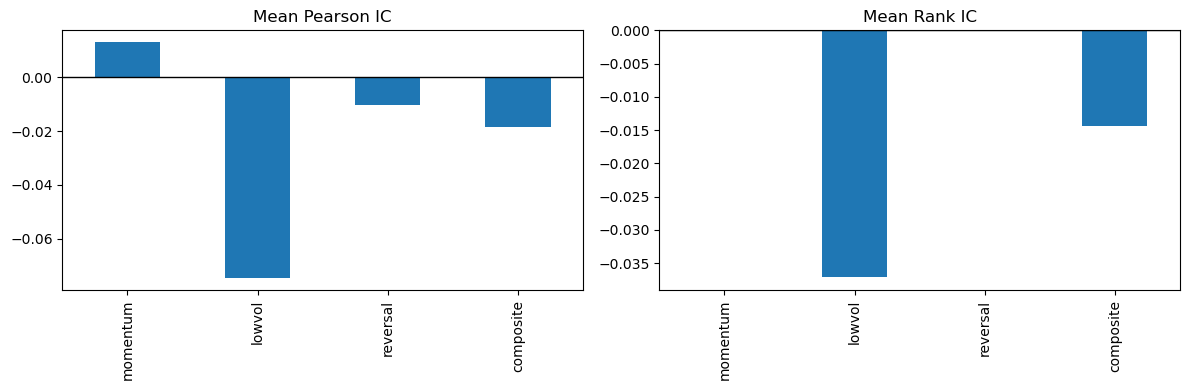

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

factor_ic.set_index("factor")["mean_ic"].plot(kind="bar", ax=axes[0], title="Mean Pearson IC")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("")

factor_ic.set_index("factor")["mean_rank_ic"].plot(kind="bar", ax=axes[1], title="Mean Rank IC")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

## Momentum Parameter Sensitivity

In [5]:
display(momentum_ic.sort_values("mean_ic", ascending=False))

mean_ic_pivot = momentum_ic.pivot(index="lookback_days", columns="skip_days", values="mean_ic")
rank_ic_pivot = momentum_ic.pivot(index="lookback_days", columns="skip_days", values="mean_rank_ic")

print("Mean Pearson IC by momentum parameters")
display(mean_ic_pivot)

print("Mean Rank IC by momentum parameters")
display(rank_ic_pivot)

,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,126,0,0.019417,0.194663,0.099747,0.561538,130.0,0.008418,0.045282,0.530769
4,189,0,0.018406,0.212392,0.086663,0.566929,127.0,0.006677,0.033224,0.543307
5,189,21,0.015450,0.203667,0.075857,0.543307,127.0,0.003444,0.017672,0.511811
6,252,0,0.015053,0.212589,0.070807,0.548387,124.0,0.001495,0.007365,0.540323
3,126,21,0.014596,0.184576,0.079076,0.523077,130.0,0.003140,0.017459,0.476923
7,252,21,0.012993,0.202867,0.064049,0.556452,124.0,-0.000146,-0.000739,0.532258
0,63,0,0.005562,0.192383,0.028910,0.526316,133.0,-0.002032,-0.011038,0.503759
1,63,21,-0.005266,0.179983,-0.029260,0.511278,133.0,-0.007739,-0.043984,0.481203


Mean Pearson IC by momentum parameters


skip_days,0,21
lookback_days,,
63,0.005562,-0.005266
126,0.019417,0.014596
189,0.018406,0.015450
252,0.015053,0.012993


Mean Rank IC by momentum parameters


skip_days,0,21
lookback_days,,
63,-0.002032,-0.007739
126,0.008418,0.003140
189,0.006677,0.003444
252,0.001495,-0.000146


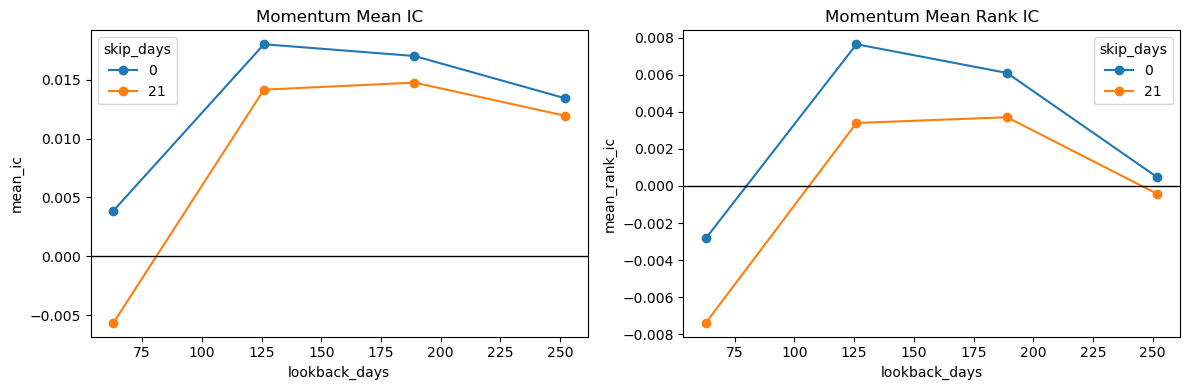

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mean_ic_pivot.plot(marker="o", ax=axes[0], title="Momentum Mean IC")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("mean_ic")

rank_ic_pivot.plot(marker="o", ax=axes[1], title="Momentum Mean Rank IC")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("mean_rank_ic")

plt.tight_layout()
plt.show()

## Momentum Parameter Sensitivity: IC vs Backtest

This section compares momentum parameter evidence from two angles: cross-sectional IC diagnostics and full backtest sensitivity. Both are useful, but they answer different questions. IC measures stock ranking quality; backtest sensitivity includes portfolio construction, benchmark weights, transaction costs, and turnover.

In [6]:
momentum_ic = read_report_csv("momentum_ic_sensitivity.csv")
momentum_backtest = read_report_csv("momentum_backtest_sensitivity.csv")

print("Momentum IC sensitivity sorted by mean Rank IC")
display(momentum_ic.sort_values("mean_rank_ic", ascending=False))

print("Momentum backtest sensitivity sorted by information ratio")
display(momentum_backtest.sort_values("information_ratio", ascending=False))

Momentum IC sensitivity sorted by mean Rank IC


,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,126,0,0.019417,0.194663,0.099747,0.561538,130.0,0.008418,0.045282,0.530769
4,189,0,0.018406,0.212392,0.086663,0.566929,127.0,0.006677,0.033224,0.543307
5,189,21,0.015450,0.203667,0.075857,0.543307,127.0,0.003444,0.017672,0.511811
3,126,21,0.014596,0.184576,0.079076,0.523077,130.0,0.003140,0.017459,0.476923
6,252,0,0.015053,0.212589,0.070807,0.548387,124.0,0.001495,0.007365,0.540323
7,252,21,0.012993,0.202867,0.064049,0.556452,124.0,-0.000146,-0.000739,0.532258
0,63,0,0.005562,0.192383,0.028910,0.526316,133.0,-0.002032,-0.011038,0.503759
1,63,21,-0.005266,0.179983,-0.029260,0.511278,133.0,-0.007739,-0.043984,0.481203


Momentum backtest sensitivity sorted by information ratio


,lookback_days,skip_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
2,126,0,13.768028,0.282263,0.207104,1.304918,-0.330816,0.573837,0.121655,0.055425,2.194956,0.048709,0.584504
0,63,0,13.957516,0.276446,0.204294,1.297756,-0.326908,0.572145,0.118474,0.054235,2.184476,0.068691,0.824292
3,126,21,13.463018,0.279794,0.208406,1.288802,-0.336198,0.576035,0.119996,0.055960,2.144318,0.054108,0.649299
4,189,0,13.076500,0.284105,0.206724,1.313895,-0.328400,0.577861,0.119322,0.055979,2.131564,0.040424,0.485086
1,63,21,13.479364,0.272709,0.205887,1.275058,-0.333488,0.572145,0.115867,0.054844,2.112658,0.085088,1.021051
5,189,21,12.927800,0.282816,0.207817,1.303233,-0.331551,0.577861,0.118543,0.056406,2.101590,0.043145,0.517742
6,252,0,13.406773,0.294552,0.207037,1.351390,-0.328316,0.577189,0.118045,0.056190,2.100810,0.035583,0.427000
7,252,21,13.289028,0.293524,0.208032,1.342089,-0.331145,0.577573,0.117456,0.056578,2.076002,0.037002,0.444026


In [7]:
momentum_comparison = momentum_ic.merge(
    momentum_backtest,
    on=["lookback_days", "skip_days"],
    how="inner",
)

comparison_columns = [
    "lookback_days",
    "skip_days",
    "mean_ic",
    "mean_rank_ic",
    "icir",
    "rank_icir",
    "annualized_active_return",
    "tracking_error",
    "information_ratio",
    "annualized_turnover",
]

display(
    momentum_comparison.loc[:, comparison_columns]
    .sort_values("information_ratio", ascending=False)
    .reset_index(drop=True)
)

,lookback_days,skip_days,mean_ic,mean_rank_ic,icir,rank_icir,annualized_active_return,tracking_error,information_ratio,annualized_turnover
0,126,0,0.019417,0.008418,0.099747,0.045282,0.121655,0.055425,2.194956,0.584504
1,63,0,0.005562,-0.002032,0.028910,-0.011038,0.118474,0.054235,2.184476,0.824292
2,126,21,0.014596,0.003140,0.079076,0.017459,0.119996,0.055960,2.144318,0.649299
3,189,0,0.018406,0.006677,0.086663,0.033224,0.119322,0.055979,2.131564,0.485086
4,63,21,-0.005266,-0.007739,-0.029260,-0.043984,0.115867,0.054844,2.112658,1.021051
5,189,21,0.015450,0.003444,0.075857,0.017672,0.118543,0.056406,2.101590,0.517742
6,252,0,0.015053,0.001495,0.070807,0.007365,0.118045,0.056190,2.100810,0.427000
7,252,21,0.012993,-0.000146,0.064049,-0.000739,0.117456,0.056578,2.076002,0.444026


The current prototype supports 126-day no-skip momentum from both IC sensitivity and backtest sensitivity: it ranks well on mean IC / Rank IC and has the strongest information ratio in the current backtest run. The 252-day momentum variants have lower turnover, so the choice is not purely about information ratio; there is a trade-off between signal responsiveness and implementation cost. These results still rely on the current static market-cap proxy when `market_cap_static` is used, which introduces look-ahead bias.

## Research Conclusion

The factor IC evidence is weak overall. Momentum is the most promising of the current factors, but the original 12-1 version is not clearly the best specification. In the tested sample, 6-month no-skip momentum appears stronger than 12-1 momentum. Low-volatility and reversal have weaker or less stable IC evidence and should be handled carefully.